# Customer Churn Analysis and Prediction  
### Machine Learning Internship Project – SaiKet Systems  

**Developed by:** Prasanna G

This project focuses on analyzing customer churn in a telecommunications company and building a machine learning model to predict customer churn.

## Objectives:
- Analyze customer data
- Build a predictive model
- Provide business insights to reduce churn

## Task 1: Data Preparation

In this step, we:
- Load the dataset
- Handle missing values
- Encode categorical variables

In [31]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Telco_Customer_Churn_Dataset.csv")

df.head()

print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [32]:
# Handle missing values
df.replace(" ", np.nan, inplace=True)
df.dropna(inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    if col != "Churn":   # 👈 ADD THIS LINE
        df[col] = le.fit_transform(df[col])

# Encode target separately
df["Churn"] = le.fit_transform(df["Churn"])

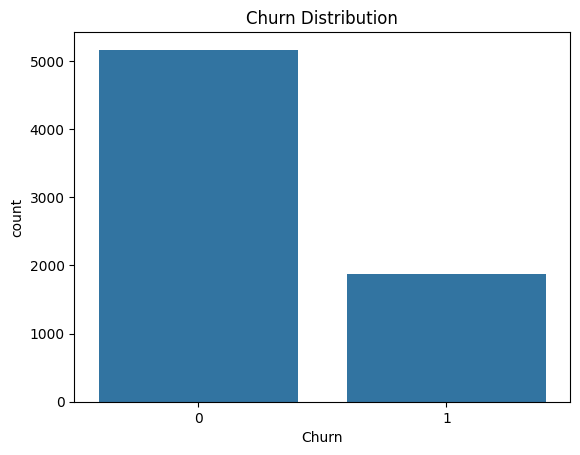

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

## Task 3: Feature Selection

Feature importance is calculated using Random Forest on the dataset to identify key factors influencing churn.

Note: This step is performed for analysis purposes.

In [35]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop("Churn", axis=1)
y = df["Churn"]

model = RandomForestClassifier()
model.fit(X, y)

import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False)

TotalCharges        0.158553
MonthlyCharges      0.149538
tenure              0.136993
customerID          0.130721
Contract            0.071608
OnlineSecurity      0.045972
PaymentMethod       0.043048
TechSupport         0.039412
OnlineBackup        0.025338
InternetService     0.024247
gender              0.023525
PaperlessBilling    0.023037
DeviceProtection    0.020100
MultipleLines       0.019241
Partner             0.018928
SeniorCitizen       0.017727
Dependents          0.017115
StreamingMovies     0.015183
StreamingTV         0.014930
PhoneService        0.004785
dtype: float64

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'TotalCharges'),
  Text(1, 0, 'MonthlyCharges'),
  Text(2, 0, 'tenure'),
  Text(3, 0, 'customerID'),
  Text(4, 0, 'Contract'),
  Text(5, 0, 'OnlineSecurity'),
  Text(6, 0, 'PaymentMethod'),
  Text(7, 0, 'TechSupport'),
  Text(8, 0, 'OnlineBackup'),
  Text(9, 0, 'InternetService')])

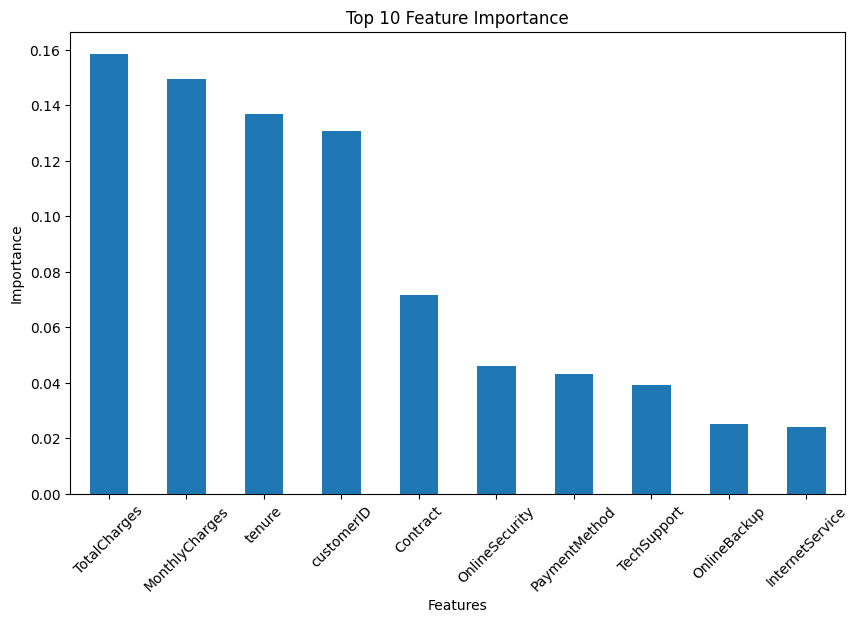

In [36]:
import matplotlib.pyplot as plt

# Sort values
feature_importance_sorted = feature_importance.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
feature_importance_sorted.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)

## Task 2: Train-Test Split

We split the dataset into:
- 80% Training Data
- 20% Testing Data

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((5625, 20), (1407, 20))

## Task 4: Model Selection

We choose Random Forest Classifier as it performs well for classification problems and handles feature importance effectively.

## Task 5: Model Training

In [38]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 🔹 Step 1: Feature Scaling (IMPORTANT)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 Step 2: Logistic Regression Model
lr = LogisticRegression(max_iter=2000)

lr.fit(X_train_scaled, y_train)

# 🔹 Step 3: Prediction
lr_pred = lr.predict(X_test_scaled)

# 🔹 Step 4: Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7860696517412935


## Task 6: Model Evaluation

We evaluate the model using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [40]:
rf_pred = model.predict(X_test)

print("===== Model Comparison =====")
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))\

from sklearn.metrics import classification_report

print("\nClassification Report:\n", classification_report(y_test, rf_pred))

===== Model Comparison =====
Random Forest Accuracy: 0.7846481876332623
Logistic Regression Accuracy: 0.7860696517412935

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.45      0.53       374

    accuracy                           0.78      1407
   macro avg       0.73      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



Text(0, 0.5, 'Accuracy')

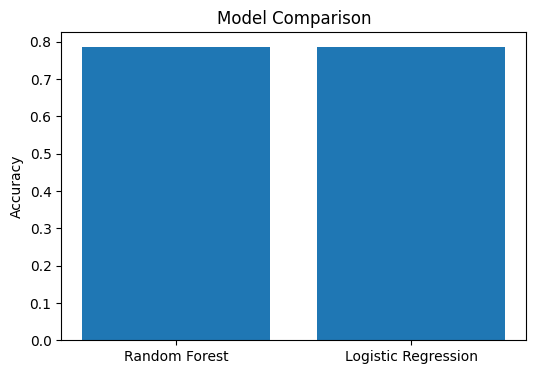

In [41]:
import matplotlib.pyplot as plt

models = ["Random Forest", "Logistic Regression"]
scores = [
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, lr_pred)
]

plt.figure(figsize=(6,4))
plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")

### Model Comparison Result

Random Forest performs better than Logistic Regression, making it the preferred model for this problem.

### Confusion Matrix Visualization

The heatmap below visualizes the performance of the Random Forest model by comparing predicted and actual values.

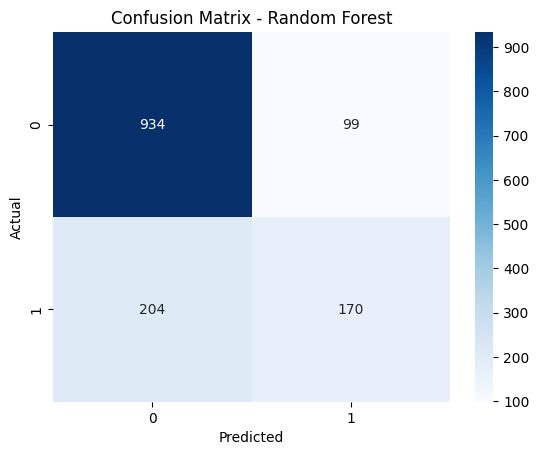

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Business Insights

- Customers with higher monthly charges are more likely to churn.
- Customers with longer tenure are less likely to churn.
- Customers with month-to-month contracts show higher churn rates.

## Recommendations

- Offer discounts to high-risk customers
- Encourage long-term contracts
- Improve customer engagement strategies

## Conclusion

The model successfully predicts customer churn and can help businesses take proactive measures to retain customers.